# Wikimedia pageviews as noisy values

Since 2015 Wikimedia has published **daily pageview counts per (country, project,
page)**, protected by differential privacy: each released count is the true count
plus calibrated noise, and counts whose *noisy* value fell below a release
threshold are suppressed entirely.  `noisyvalue.wikimedia` reads these files and
attaches to every count the posterior of its true value, so uncertainty flows
through everything you compute downstream.

There are three eras, each with its own mechanism (all boundaries below were
validated against the released files themselves — see `test/test_wikimedia.py`):

| era | dates | noise | threshold |
| --- | --- | --- | --- |
| pre-2017 | 2015-07-01 – 2017-02-08 | geometric, scale 300 | 3500 |
| historical | 2017-02-09 – 2023-02-05 | geometric, scale 30 | 450 |
| current | 2023-02-06 – present | discrete Gaussian (zCDP), σ ≈ 18 / 90 / 180 by country risk tier | 90 / 550 / 1000 |

Two semantic caveats worth knowing before reading any number:

- A count is **deduplicated and clipped** — in the current era each device
  contributes at most its first 10 unique pageviews per day — so it sits below
  the exact figures of the public pageview API.
- The historical eras did **not filter automated traffic**; their sums track the
  API's *all-agents* totals, and data-center countries sometimes carry most of a
  page's count.  The current era counts via a browser cookie and tracks human
  traffic.

This notebook follows one page — the English Wikipedia article on the **2018
FIFA World Cup Final** — through the fortnight around the match (France beat
Croatia 4–2 on 15 July 2018), then uses one page on two adjacent days to show a
subtler feature: files that mix two noise mechanisms.

The first cell mirrors ~16 daily files (about 100 MB) into `data/` at the repo
root; nothing is fetched implicitly after that.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from noisyvalue import fetch_pageviews, get_pageviews, plot_posterior, sample_noisy_values
from noisyvalue.wikimedia import days_between

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "pyproject.toml").exists()) / "data" / "wikimedia-pageviews"

plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25})

final_days = days_between("2018-07-09", "2018-07-22")
paths = fetch_pageviews(final_days, root=ROOT)
paths += fetch_pageviews(["2023-05-01", "2023-05-02"], root=ROOT)
print(f"{len(paths)} daily files mirrored under {ROOT}")

16 daily files mirrored under /home/sbaldasty/code/github/sbaldasty/noisyvalue/data/wikimedia-pageviews


## A tidy frame

`get_pageviews` returns one row per released (country, day) cell.  The `value`
column holds a `NoisyIntArray`: each entry is the released count *plus its
posterior* — under the library's flat prior, the true count is the observation
minus a fresh draw of the mechanism's noise, truncated to be nonnegative.  The
`mechanism` and `variance` columns say which noise law produced each row.

In [2]:
wc = get_pageviews(final_days, page="2018 FIFA World Cup Final",
                   project="en.wikipedia", root=ROOT)
print(f"{len(wc)} released (country, day) cells across {wc['country_code'].nunique()} countries")

final = wc[wc["date"] == "2018-07-15"]
final.assign(count=final["value"].array._obs).nlargest(6, "count")[
    ["date", "country", "page_title", "value", "variance", "mechanism"]]

152 released (country, day) cells across 39 countries


,date,country,page_title,value,variance,mechanism
106,2018-07-15,India,2018_FIFA_World_Cup_Final,~38768,1799.833343,"geometric scale 30 (epsilon=1, m=30)"
73,2018-07-15,United States of America,2018_FIFA_World_Cup_Final,~37777,1799.833343,"geometric scale 30 (epsilon=1, m=30)"
74,2018-07-15,United Kingdom,2018_FIFA_World_Cup_Final,~11091,1799.833343,"geometric scale 30 (epsilon=1, m=30)"
87,2018-07-15,Canada,2018_FIFA_World_Cup_Final,~7563,1799.833343,"geometric scale 30 (epsilon=1, m=30)"
96,2018-07-15,Indonesia,2018_FIFA_World_Cup_Final,~4855,1799.833343,"geometric scale 30 (epsilon=1, m=30)"
77,2018-07-15,Malaysia,2018_FIFA_World_Cup_Final,~4150,1799.833343,"geometric scale 30 (epsilon=1, m=30)"


## The posterior of one count

Croatia's readers on the day of the final: the released figure is 1086, and the
posterior spreads it with the historical era's geometric noise (scale 30,
standard deviation ≈ 42).  `plot_posterior` renders the density deterministically
by quadrature — no Monte Carlo.  Suppression does not bias this: since the noisy
value itself is observed, clearing the threshold adds no further information.

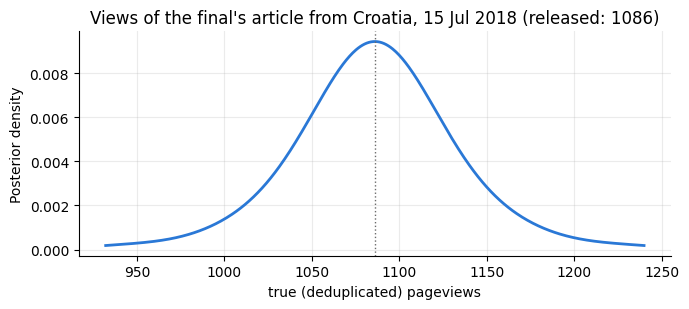

In [3]:
hr_final = final.set_index("country_code")["value"]["HR"]

fig, ax = plt.subplots(figsize=(7, 3.2))
plot_posterior(hr_final, ax=ax)
ax.get_lines()[0].set_color("#2a78d6")
ax.axvline(int(hr_final), color="#6b6b6b", linewidth=1, linestyle=":")
ax.set_title(f"Views of the final's article from Croatia, 15 Jul 2018 (released: {int(hr_final)})")
ax.set_xlabel("true (deduplicated) pageviews")
plt.tight_layout()

## A time series that knows its own uncertainty

Sampling each cell's posterior gives a median line and a 90% band per country.
At this scale the bands are barely wider than the lines — a count of a few
thousand carries noise of only a few dozen — which is itself the point: the
privacy noise is small exactly where the signal is large.  The lines *break*
where a country has no row, and that is data, not absence of data: a missing
day means the noisy count fell below 450.  France drops out on 9 and 13 July
while Great Britain never leaves; Croatia surfaces only in the final week.

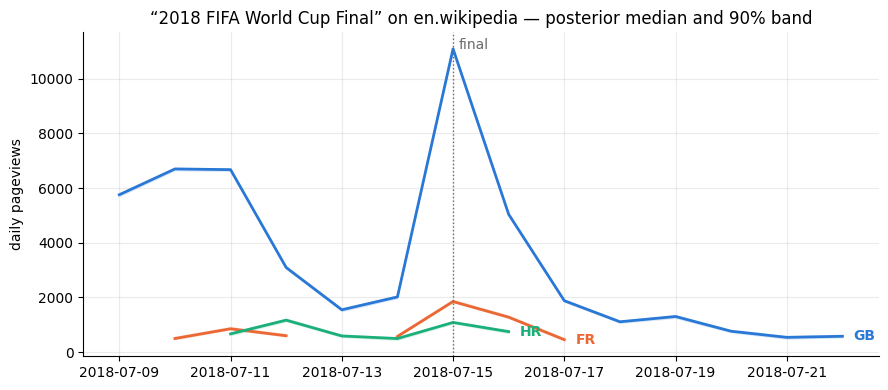

In [4]:
COLORS = {"GB": "#2a78d6", "FR": "#eb6834", "HR": "#1baf7a"}   # fixed hue order
idx = pd.to_datetime(final_days)

fig, ax = plt.subplots(figsize=(9, 4))
for k, (code, color) in enumerate(COLORS.items()):
    sub = wc[wc["country_code"] == code]
    draws = np.stack([v.sample(800, rng=10 * k + j).draws
                      for j, v in enumerate(sub["value"])])
    lo, mid, hi = (pd.Series(q, index=sub["date"]).reindex(idx)
                   for q in np.percentile(draws, [5, 50, 95], axis=1))
    ax.fill_between(idx, lo, hi, color=color, alpha=0.18, linewidth=0)
    ax.plot(idx, mid, color=color, linewidth=2)
    last_date = sub["date"].iloc[-1]        # label at the last released day
    ax.annotate(code, (last_date, mid.loc[last_date]), xytext=(8, 0),
                textcoords="offset points", color=color,
                fontweight="bold", va="center")
ax.axvline(pd.Timestamp("2018-07-15"), color="#6b6b6b", linewidth=1, linestyle=":")
ax.annotate("final", (pd.Timestamp("2018-07-15"), ax.get_ylim()[1]),
            xytext=(4, -12), textcoords="offset points", color="#6b6b6b")
ax.set_title("\u201c2018 FIFA World Cup Final\u201d on en.wikipedia \u2014 posterior median and 90% band")
ax.set_ylabel("daily pageviews")
plt.tight_layout()

## Absence is censoring, not zero

The released counts for the three countries make the suppression visible: a
blank cell means the noisy count was below 450 that day.  Treating blanks as
zeros would bias any aggregate you build from this table — the correct reading
of a blank is "somewhere below ≈450, we don't know where".

In [5]:
table = wc.assign(count=wc["value"].array._obs).pivot_table(
    index="country_code", columns=wc["date"].dt.day, values="count")
table.columns.name = "July 2018"
table.loc[["GB", "FR", "HR"]]

July 2018,9,10,11,12,13,14,15,16,17,18,19,20,21,22
country_code,,,,,,,,,,,,,,
GB,5758.0,6699.0,6673.0,3093.0,1550.0,2018.0,11091.0,5038.0,1879.0,1109.0,1303.0,762.0,540.0,580.0
FR,NaN,498.0,852.0,599.0,NaN,573.0,1851.0,1277.0,457.0,NaN,NaN,NaN,NaN,NaN
HR,NaN,NaN,666.0,1169.0,590.0,497.0,1086.0,753.0,NaN,NaN,NaN,NaN,NaN,NaN


Since an absence *is* an observation, it can carry a posterior of its own.
`missing="censored"` returns requested-but-absent cells with the distribution
absence implies — the noisy count stayed below 450, so the true count is
essentially uniform below the threshold, rolling off through the noise's
upper tail.  Croatia's quiet days get wide but honest intervals; such rows
are flagged `censored=True`, and their observation column is the posterior
median, since nothing was released.

In [6]:
hr_days = set(wc[wc["country_code"] == "HR"]["date"].dt.date)
gaps = [day for day in final_days if day not in hr_days]
cens = get_pageviews(gaps, country=["HR"], project="en.wikipedia",
                     page="2018 FIFA World Cup Final",
                     missing="censored", root=ROOT)
bands = np.stack([np.percentile(v.sample(2000, rng=31).draws, [5, 95])
                  for v in cens["value"]])
pd.DataFrame({"date": cens["date"].dt.date, "censored": cens["censored"],
              "posterior 5%": bands[:, 0].astype(int),
              "posterior 95%": bands[:, 1].astype(int)})

,date,censored,posterior 5%,posterior 95%
0,2018-07-09,True,24,435
1,2018-07-10,True,24,435
2,2018-07-17,True,24,435
3,2018-07-18,True,24,435
4,2018-07-19,True,24,435
5,2018-07-20,True,24,435
6,2018-07-21,True,24,435
7,2018-07-22,True,24,435


## Comparing two noisy counts

On the eve of the final, France released 573 and Croatia 497 — a gap of 76
against a combined noise standard deviation of about 60.  Were there really more
French than Croatian readers?  Because both operands carry their posteriors, the
comparison is itself a noisy value, and sampling it *jointly* answers with a
probability rather than a yes.

In [7]:
eve = wc[wc["date"] == "2018-07-14"].set_index("country_code")["value"]
fr, hr = eve["FR"], eve["HR"]

prob = (fr > hr).sample(8000, rng=21).draws.mean()
diff = (fr - hr).sample(8000, rng=22).draws
print(f"released: FR {int(fr)}, HR {int(hr)}")
print(f"P(true FR count > true HR count) \u2248 {prob:.2f}")
print(f"90% interval for the difference: {np.percentile(diff, 5):+.0f} .. {np.percentile(diff, 95):+.0f}")

released: FR 573, HR 497
P(true FR count > true HR count) ≈ 0.91
90% interval for the difference: -25 .. +173


## Two mechanisms in one file

The current era is Gaussian — except where history intervened.  A database
naming error dropped most United States rows between February and September
2023, and the affected days were later repaired with the *historical* geometric
mechanism.  The failure was intermittent, day by day: on 1 May 2023 the pipeline
succeeded (ordinary Gaussian US rows, σ ≈ 18), and on 2 May it failed (backfilled
geometric US rows, σ ≈ 42).  `get_pageviews` routes this per row — same page,
adjacent days, and the US posterior more than doubles in width while France's
stays put.

,date,country_code,value,variance,mechanism
8,2023-05-01,US,~3993,332.225914,discrete Gaussian zCDP rho=0.01505 (lower risk)
21,2023-05-02,US,~4244,1799.833343,"geometric scale 30 (epsilon=1, m=30)"


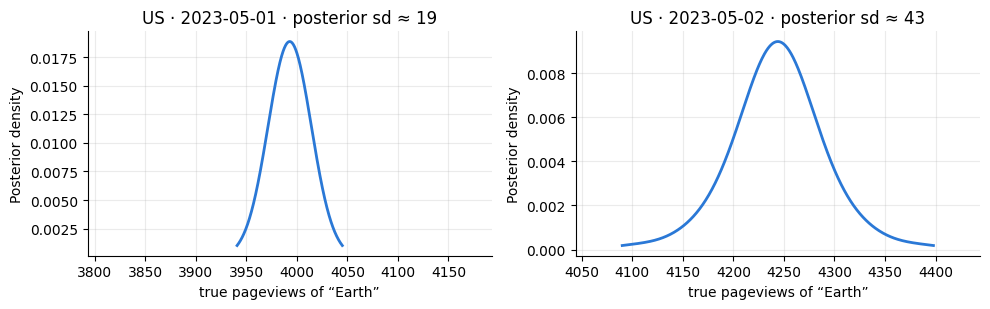

In [8]:
earth = get_pageviews(["2023-05-01", "2023-05-02"], page="Earth",
                      project="en.wikipedia", root=ROOT)
us_fr = earth[earth["country_code"].isin(["US", "FR"])]
display(us_fr[["date", "country_code", "value", "variance", "mechanism"]])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
us = earth[earth["country_code"] == "US"]
for ax, date, value in zip(axes, us["date"], us["value"]):
    plot_posterior(value, ax=ax)
    ax.get_lines()[0].set_color("#2a78d6")
    sd = value.sample(4000, rng=3).draws.std()
    ax.set_title(f"US \u00b7 {date.date()} \u00b7 posterior sd \u2248 {sd:.0f}")
    ax.set_xlabel("true pageviews of \u201cEarth\u201d")
    ax.set_xlim(int(value) - 200, int(value) + 200)   # equal spans, honest widths
plt.tight_layout()

## Repeated reads agree

Each cell's noise symbol is derived from its identity (day, country, project,
page), so reading the same cell in two separate calls yields the *same* random
variable — expressions that combine the two sample consistently, with no view or
session object to carry around.

In [9]:
kwargs = dict(country="HR", page="2018 FIFA World Cup Final",
              project="en.wikipedia", root=ROOT)
a = get_pageviews("2018-07-15", **kwargs)["value"][0]
b = get_pageviews("2018-07-15", **kwargs)["value"][0]
batch_a, batch_b = sample_noisy_values(a, b, n=500, rng=8)
print("two reads, one random variable:", np.array_equal(batch_a.draws, batch_b.draws))

two reads, one random variable: True


## Where to go from here

- `noisyvalue.wikimedia`'s module docstring documents the codebook: the era
  registry, the country risk tiers and their dated revisions, the never-released
  days, and the derivation of every constant.
- `days_between(start, end)` builds fetchable ranges; a day file runs ~6 MB in
  the historical eras and ~25–60 MB in the current one.
- The census loaders (`get_pl94`, `get_dhc`) return the same tidy shape, so
  analyses compose across datasets.
- `docs/wikimedia-errata.md` collects everything the files do that the
  official documentation does not say, and
  `docs/wikimedia-true-pageviews.md` sketches the path from these bounded,
  deduplicated counts to posteriors over *actual* pageviews.